# Generation script to prepare regrounding for evaluation 

# Look at extractslices for a script

In [2]:
import json
import pandas as pd
from huggingface_hub import hf_hub_download


# Load the dataset.json file
with open("/vol/idea_longterm/datasets/CT-RATE-Segmentations/dataset.json", "r") as f:
    data = json.load(f)

# Extract all 'name' fields
names = [entry["name"] for entry in data["train"]]
names += [entry["name"] for entry in data["train"]]
names[:3]

/home/rrzelinuxhome/ed52egek/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


['train_1741_b_2.nii.gz', 'train_1935_a_1.nii.gz', 'train_1591_f_2.nii.gz']

In [3]:
data["test"][0]

{'name': 'train_13195_a_1.nii.gz',
 'findings': {'0': 'Subpleural ground glass opacity in the posterobasal segment of the right lower lobe',
  '1': 'Subpleural ground glass opacity in the anterobasal segment of the left lower lobe'},
 'shape': [512, 512, 202],
 'categories': {'0': '2c', '1': '2c'},
 'protocol': 'test'}

In [4]:
# Create lists to store the data
names = []
finding_keys = []
findings = []
splits = []
categories = []

# Extract data from train entries
for split in ["train", "val", "test"]:
    for entry in data[split]:
        name = entry["name"]
        for key, finding in entry["findings"].items():
            names.append(name)
            finding_keys.append(key)
            findings.append(finding)
            splits.append(split)
            categories.append(entry["categories"][key])

# Create dataframe
df = pd.DataFrame({
    "name": names,
    "finding_key": finding_keys, 
    "finding": findings,
    "categories": categories,
    "Split": splits
})

df.to_csv("ctflow.csv")
df

,name,finding_key,finding,categories,Split
0,train_1741_b_2.nii.gz,0,Irregularly circumscribed nodular consolidatio...,2b,train
1,train_1935_a_1.nii.gz,0,Segmental and subsegmental peribronchial thick...,1a,train
2,train_1935_a_1.nii.gz,1,Mosaic attenuation pattern in both lungs,2c,train
3,train_1935_a_1.nii.gz,2,Reticulonodular density increases in both lung...,1d,train
4,train_1935_a_1.nii.gz,3,Paraseptal emphysema in both lung apices,1c,train
...,...,...,...,...,...
8023,train_13051_a_1.nii.gz,3,Linear atelectasis areas in the left upper lob...,2a,test
8024,train_13051_a_1.nii.gz,4,Significant increase in dependent density in b...,2b,test
8025,train_13240_b_2.nii.gz,0,Diffuse ground glass opacities in both lungs h...,2c,test
8026,train_13240_b_2.nii.gz,1,Subcentimeter nonspecific stable nodules in bo...,2d,test


In [5]:
df["Split"].value_counts()

Split
train    7687
test      226
val       115
Name: count, dtype: int64

# Usage

In [6]:
from os.path import join
import torch 
import nibabel as nib
import pandas as pd
from pathlib import Path
import numpy as np

def load_gt_mask(path, finding_key=None): 
    from huggingface_hub import hf_hub_download
    repo_id = "rajpurkarlab/ReXGroundingCT"
    file_path = hf_hub_download(
        repo_id=repo_id,
        filename=f"segmentations/{path}",
        repo_type="dataset"
    )
    nifti_img = nib.load(file_path)
    nifti_data = nifti_img.get_fdata()
    if finding_key is None:
        # Sum all finding key masks together
        return torch.Tensor(nifti_data).clip(0, 1)
    else:
        return torch.Tensor(nifti_data[int(finding_key)]).clip(0, 1)

def name_to_path(name):
    # Convert name from grounding.csv to full path
    parts = name.split('_')  # e.g. train_1741_b_2.nii.gz -> ['train', '1741', 'b', '2.nii.gz']
    folder = f"{parts[0]}_{parts[1]}"  # train_1741
    subfolder = f"{folder}_{parts[2]}"  # train_1741_b
    path = Path(f"/vol/idea_longterm/datasets/CT-RATE/dataset/{parts[0]}/{folder}/{subfolder}/{name}")
    return path

def load_gt_in(name): 
    path = name_to_path(name)
    img = nib.load(str(path), mmap=True)
    vol = img.get_fdata(dtype=np.float32)
    return torch.tensor(vol)


pd.read_csv("ctflow.csv")

,Unnamed: 0,name,finding_key,finding,categories,Split
0,0,train_1741_b_2.nii.gz,0,Irregularly circumscribed nodular consolidatio...,2b,train
1,1,train_1935_a_1.nii.gz,0,Segmental and subsegmental peribronchial thick...,1a,train
2,2,train_1935_a_1.nii.gz,1,Mosaic attenuation pattern in both lungs,2c,train
3,3,train_1935_a_1.nii.gz,2,Reticulonodular density increases in both lung...,1d,train
4,4,train_1935_a_1.nii.gz,3,Paraseptal emphysema in both lung apices,1c,train
...,...,...,...,...,...,...
8023,8023,train_13051_a_1.nii.gz,3,Linear atelectasis areas in the left upper lob...,2a,test
8024,8024,train_13051_a_1.nii.gz,4,Significant increase in dependent density in b...,2b,test
8025,8025,train_13240_b_2.nii.gz,0,Diffuse ground glass opacities in both lungs h...,2c,test
8026,8026,train_13240_b_2.nii.gz,1,Subcentimeter nonspecific stable nodules in bo...,2d,test


In [40]:
from scipy import ndimage as ndi

def bbox_from_mask(mask: np.ndarray, connectivity: int = 1, min_voxels: int = 40):
    if mask.ndim != 3:
        raise ValueError(f"Expected a 3D mask (Z,Y,X), got shape {mask.shape}")

    if mask.shape[0] == mask.shape[1] and mask.shape[1] != mask.shape[2]:
        mask = mask.transpose((2, 0, 1))


    structure = ndi.generate_binary_structure(3, connectivity)
    labeled, num = ndi.label(mask, structure=structure)
    if num == 0:
        return []

    # Fast per-label voxel counts to filter tiny components
    counts = np.bincount(labeled.ravel())
    # Slices are half-open: slice.start .. slice.stop (exclusive)
    slices = ndi.find_objects(labeled)

    boxes = []
    for lbl, slc in enumerate(slices, start=1):
        if slc is None:
            continue
        if counts[lbl] < min_voxels:
            continue
        zslice, yslice, xslice = slc
        x_min, y_min, z_min = xslice.start, yslice.start, zslice.start
        dx = xslice.stop - xslice.start
        dy = yslice.stop - yslice.start
        dz = zslice.stop - zslice.start
        boxes.append((x_min, y_min, z_min, dx, dy, dz))
    return boxes


idx = 10  
#finding_key = df.iloc[idx]["finding_key"]
path = df.iloc[idx]["name"]


gt_mask = load_gt_mask(path, None)
masks = [bbox_from_mask(gt_mask[i].transpose(2, 1).transpose(0, 1)) for i in range(len(gt_mask))]
print(gt_mask.size())
print(gt_mask.sum(axis=0).size())
df.iloc[idx]

torch.Size([5, 512, 512, 466])
torch.Size([512, 512, 466])


name                            train_1591_f_2.nii.gz
finding_key                                         4
finding        Fibroatelectatic changes in both lungs
categories                                         2b
Split                                           train
Name: 10, dtype: object

In [1]:
path

NameError: name 'path' is not defined

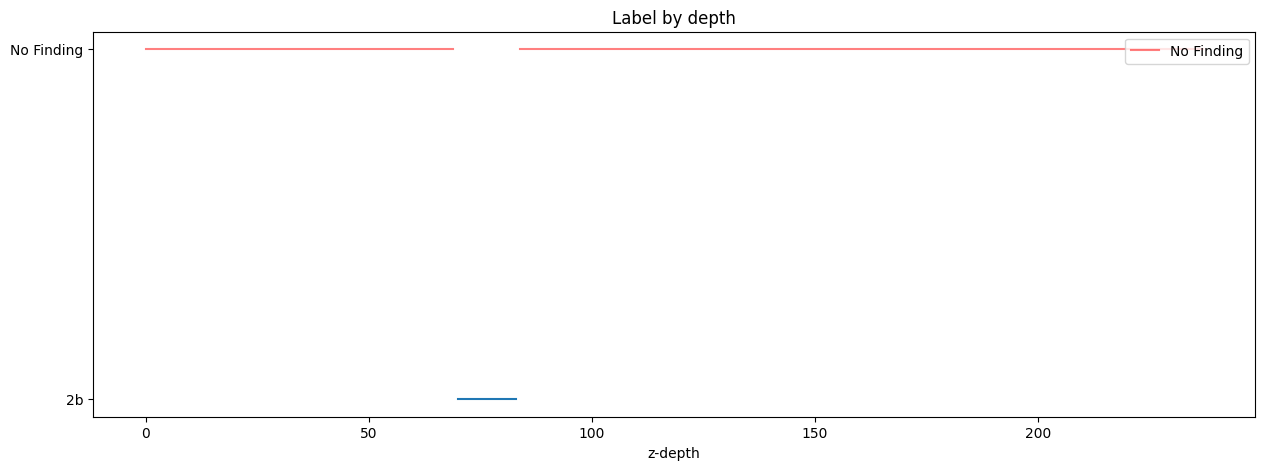

In [45]:
import numpy as np
import matplotlib.pyplot as plt

def contiguous_runs(mask_bool):
    """Return [(start, end), ...] for contiguous True runs in a 1D boolean array."""
    a = np.asarray(mask_bool, dtype=bool)
    if a.size == 0:
        return []
    diffs = np.diff(np.pad(a.astype(int), (1, 1)))
    starts = np.where(diffs == 1)[0]
    ends   = np.where(diffs == -1)[0]
    return list(zip(starts, ends))

def plot_findings_by_depth(gt_mask, masks, df, path):
    """Plot findings and no-finding regions by z-depth.
    
    Args:
        gt_mask: Ground truth mask tensor
        masks: List of bounding boxes for each finding
        df: DataFrame containing finding metadata
        path: Path/name of the current case
    """
    z_max = int(gt_mask.size()[-1])
    fig, axs = plt.subplots(figsize=(15, 5))

    # Track where any finding is present
    has_finding = np.zeros(z_max, dtype=bool)

    # Plot findings
    for i, masks_ in enumerate(masks):
        row = df[(df["name"] == path) & (df["finding_key"] == str(i))]
        category = row["categories"].iloc[0] if len(row) else f"cat_{i}"

        for mask in masks_:
            z_start = int(mask[2])
            length  = int(mask[5])
            z_stop  = min(z_start + length, z_max)
            if z_start >= z_stop:
                continue
            has_finding[z_start:z_stop] = True
            axs.plot(np.arange(z_start, z_stop),
                     [category] * (z_stop - z_start))

    # Split zeros into contiguous segments and plot each separately
    no_runs = contiguous_runs(~has_finding)
    for j, (s, e) in enumerate(no_runs):
        axs.plot(np.arange(s, e),
                 ["No Finding"] * (e - s),
                 c="red",
                 alpha=0.5,
                 label="No Finding" if j == 0 else None)

    axs.set_title("Label by depth")
    axs.set_xlabel("z-depth")
    axs.legend(loc="upper right")
    plt.show()

# Call the function with current variables
plot_findings_by_depth(gt_mask, masks, df, path)